In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar

import config as cfg

cfg.apply_matplotlib_styles()

gbif_file_path = "/home/takayuki/Desktop/summer2025/plants/data/study_area_data/whole_world_occournce_data/0020096-250802193616735.csv"
states_shapefile_path = "/home/takayuki/Desktop/summer2025/plants/data/study_area_data/ne_110m_admin_1_states_provinces/ne_110m_admin_1_states_provinces.shp"

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Global Matplotlib styles applied.


/home/takayuki/.local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:
df = pd.read_csv(gbif_file_path, sep='\t', index_col='gbifID', low_memory=False)
df.columns

Index(['datasetKey', 'occurrenceID', 'kingdom', 'phylum', 'class', 'order',
       'family', 'genus', 'species', 'infraspecificEpithet', 'taxonRank',
       'scientificName', 'verbatimScientificName',
       'verbatimScientificNameAuthorship', 'countryCode', 'locality',
       'stateProvince', 'occurrenceStatus', 'individualCount',
       'publishingOrgKey', 'decimalLatitude', 'decimalLongitude',
       'coordinateUncertaintyInMeters', 'coordinatePrecision', 'elevation',
       'elevationAccuracy', 'depth', 'depthAccuracy', 'eventDate', 'day',
       'month', 'year', 'taxonKey', 'speciesKey', 'basisOfRecord',
       'institutionCode', 'collectionCode', 'catalogNumber', 'recordNumber',
       'identifiedBy', 'dateIdentified', 'license', 'rightsHolder',
       'recordedBy', 'typeStatus', 'establishmentMeans', 'lastInterpreted',
       'mediaType', 'issue'],
      dtype='object')

In [3]:
df_imp = df[['species', 'scientificName', 'decimalLatitude', 'decimalLongitude', 'countryCode']]
df_imp.columns = ['species', 'scientificName', 'decimalLatitude', 'decimalLongitude', 'countryCode']

print(f"Total number of records: {len(df_imp)}")

# drop rows with missing species 
numnan = df_imp['species'].isna().sum()
df_imp['species'] = df_imp['species'].fillna(df_imp['scientificName'])
filled = numnan - df_imp['species'].isna().sum()
print(f"\nBorrowed species names from scientificName for {filled} records.")

df_imp = df_imp.dropna(subset=['species'])
print(f'Dropped {len(df) - len(df_imp)} records due to missing species.')

species_list = df_imp['species'].unique().tolist()
print(f"\nFound {len(species_list)} unique species in the dataset.")

# drop rows with missing geographic coordinates
df_geo = df_imp.dropna(subset=['decimalLatitude', 'decimalLongitude'])
print(f"\nNumber of records with valid geographic coordinates: {len(df_geo)}")
print(f"Dropped {len(df_imp) - len(df_geo)} records due to missing coordinates.")
print(f"Dropped following species with no coordinates ({df_imp['species'].nunique() - df_geo['species'].nunique()})")
dropped_species = set(df_imp['species']) - set(df_geo['species'])
for spec in dropped_species:
    print(f"  - {spec}")

# Merge all cabomba species into one (all that start with 'Cabomba')
num_cabombas = pd.Series(df_geo['species'].unique()).str.startswith('Cabomba').sum()
df_geo['species'] = df_geo['species'].replace(
    r'^Cabomba.*', 'Cabomba', regex=True)
print(f"Merged {num_cabombas} species into 'Cabomba'.")

# 
print("-"* 50, end="")
print("\nS.No \t Species/variety \t\t Count")
print("-"* 50)
i = 0
for spec, count in sorted(df_geo['species'].value_counts().items(), key = lambda x: x[0]):
    i += 1
    spec_spaced = spec.ljust(25)
    print(f"{i} \t {spec_spaced} \t {count}")

Total number of records: 972436

Borrowed species names from scientificName for 173 records.
Dropped 0 records due to missing species.


/tmp/ipykernel_12027/2473730255.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_imp['species'] = df_imp['species'].fillna(df_imp['scientificName'])



Found 28 unique species in the dataset.

Number of records with valid geographic coordinates: 972436
Dropped 0 records due to missing coordinates.
Dropped following species with no coordinates (0)
Merged 8 species into 'Cabomba'.
--------------------------------------------------
S.No 	 Species/variety 		 Count
--------------------------------------------------
1 	 Brasenia schreberi        	 8954
2 	 Cabomba                   	 7521
3 	 Ceratophyllum demersum    	 138415
4 	 Elodea canadensis         	 109966
5 	 Heteranthera dubia        	 2602
6 	 Hydrocharis morsus-ranae  	 115403
7 	 Myriophyllum sibiricum    	 15293
8 	 Myriophyllum spicatum     	 160381
9 	 Najas flexilis            	 4781
10 	 Nitellopsis obtusa        	 23933
11 	 Nuphar variegata          	 7075
12 	 Nymphaea odorata          	 22167
13 	 Potamogeton crispus       	 85096
14 	 Potamogeton gramineus     	 37589
15 	 Potamogeton illinoensis   	 2441
16 	 Potamogeton natans        	 174120
17 	 Potamogeton prae

In [4]:
needed_species = cfg.CANONICAL_CLASSNAMES_LIST
falg = True
for i, spec in enumerate(needed_species):
    print(f"{i+1} \t {spec.ljust(25)}", end ="")
    if spec not in df_geo['species'].unique():
        print(" \t Not found in dataset")
        falg = False
    else:
        print()
if falg:
    print("\nAll species found in the dataset.")

1 	 Brasenia schreberi       
2 	 Cabomba                  
3 	 Ceratophyllum demersum   
4 	 Elodea canadensis        
5 	 Heteranthera dubia       
6 	 Hydrocharis morsus-ranae 
7 	 Myriophyllum sibiricum   
8 	 Myriophyllum spicatum    
9 	 Najas flexilis           
10 	 Nitellopsis obtusa       
11 	 Nuphar variegata         
12 	 Nymphaea odorata         
13 	 Potamogeton crispus      
14 	 Potamogeton gramineus    
15 	 Potamogeton illinoensis  
16 	 Potamogeton natans       
17 	 Potamogeton praelongus   
18 	 Potamogeton richardsonii 
19 	 Potamogeton robbinsii    
20 	 Ranunculus aquatilis     
21 	 Vallisneria americana    

All species found in the dataset.


In [5]:
gdf_plants = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo.decimalLongitude, df_geo.decimalLatitude),
    crs="EPSG:4326"  # CRS for standard latitude/longitude
)

usa = gpd.read_file(states_shapefile_path)
michigan_boundary = usa[usa['name'] == 'Michigan']

gdf_plants_michigan = gpd.sjoin(gdf_plants, michigan_boundary, how="inner", predicate="within")
print(f"Found {len(gdf_plants_michigan)} of {len(df_geo)} records with coordinates located within Michigan.")

#
print("-"* 50, end="")
print("\nS.No \t Species/variety \t\t Count")
print("-"* 50)
i = 0
for spec, count in sorted(gdf_plants_michigan['species'].value_counts().items(), key = lambda x: x[0]):
    i += 1
    spec_spaced = spec.ljust(25)
    print(f"{i} \t {spec_spaced} \t {count}")


Found 17252 of 972436 records with coordinates located within Michigan.
--------------------------------------------------
S.No 	 Species/variety 		 Count
--------------------------------------------------
1 	 Brasenia schreberi        	 336
2 	 Cabomba                   	 92
3 	 Ceratophyllum demersum    	 260
4 	 Elodea canadensis         	 280
5 	 Heteranthera dubia        	 111
6 	 Hydrocharis morsus-ranae  	 10539
7 	 Myriophyllum sibiricum    	 199
8 	 Myriophyllum spicatum     	 1027
9 	 Najas flexilis            	 230
10 	 Nitellopsis obtusa        	 475
11 	 Nuphar variegata          	 499
12 	 Nymphaea odorata          	 1251
13 	 Potamogeton crispus       	 526
14 	 Potamogeton gramineus     	 414
15 	 Potamogeton illinoensis   	 204
16 	 Potamogeton natans        	 225
17 	 Potamogeton praelongus    	 135
18 	 Potamogeton richardsonii  	 181
19 	 Potamogeton robbinsii     	 94
20 	 Ranunculus aquatilis      	 4
21 	 Vallisneria americana     	 170


/tmp/ipykernel_12027/3156231752.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(species_list))


FileNotFoundError: [Errno 2] No such file or directory: '/home/takayuki/Desktop/summer2025/plants/plant_classification/figures/map.pdf'

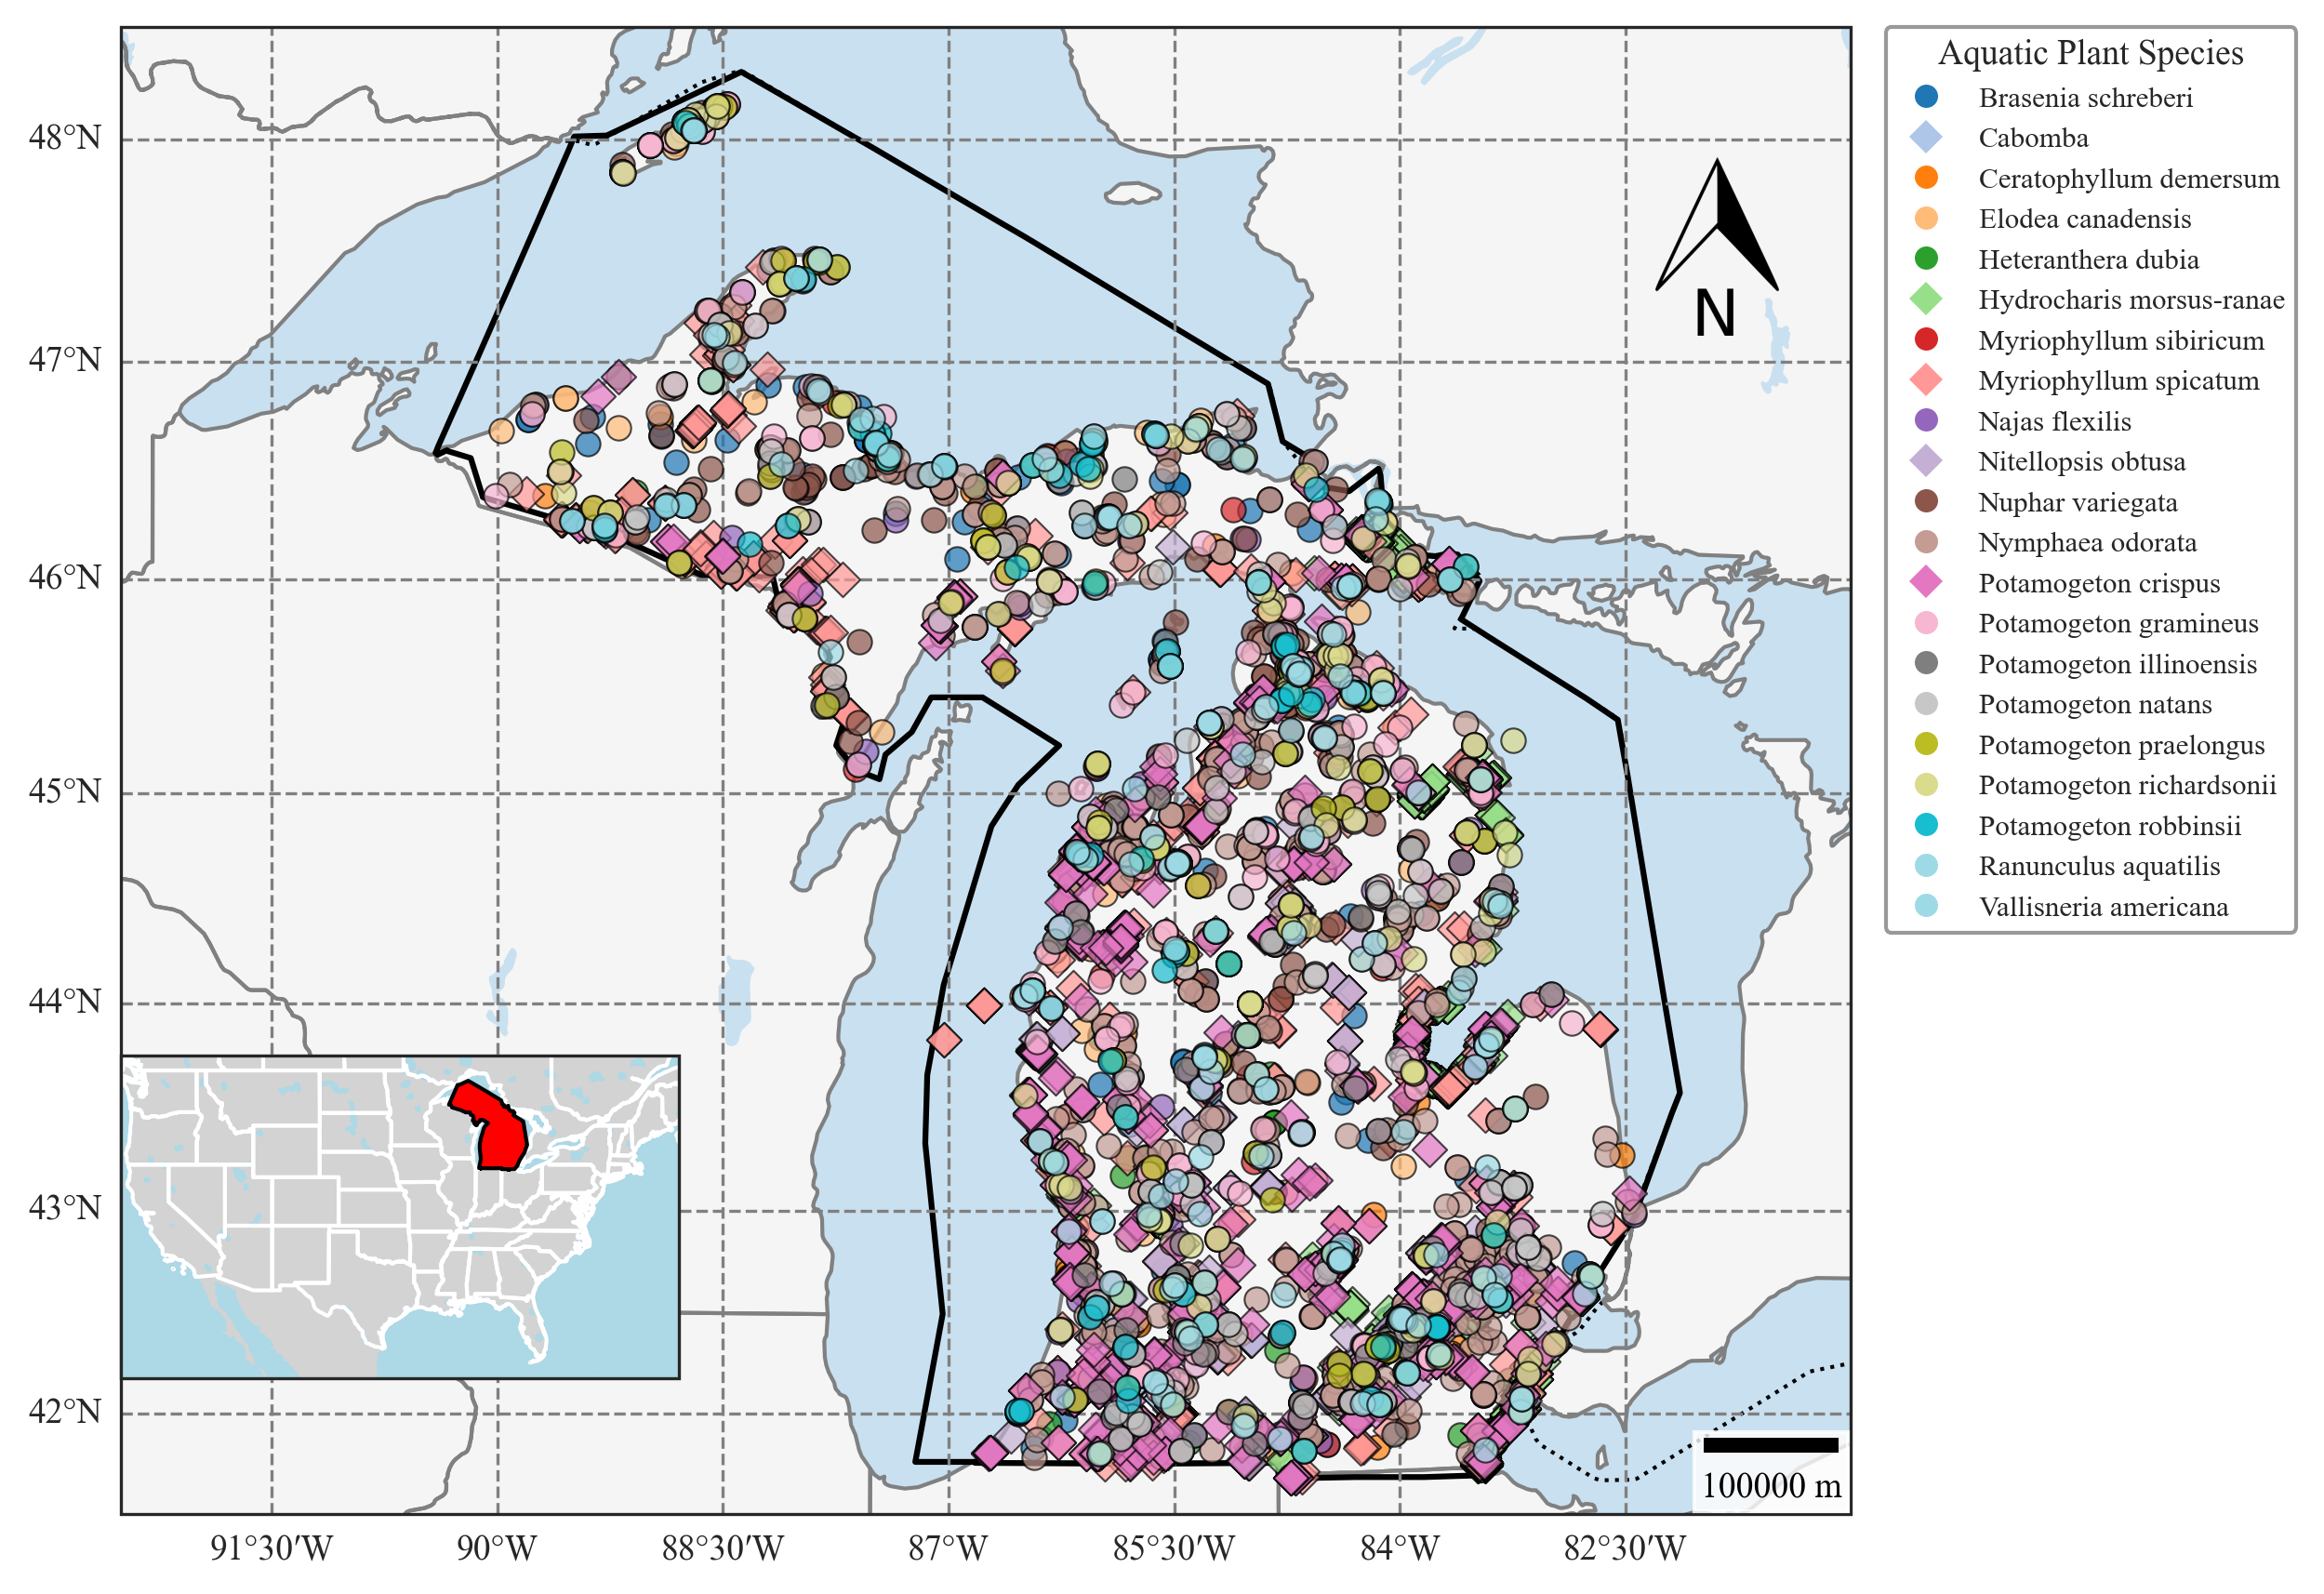

In [6]:
# Define map projections
map_proj = ccrs.Mercator()
data_proj = ccrs.PlateCarree()

# Create a figure and main axes
fig = plt.figure(figsize=(8, 8))
ax_main = fig.add_subplot(1, 1, 1, projection=map_proj)

# Set the extent to focus on Michigan
ax_main.set_extent([-92.5, -81, 41.5, 48.5], crs=data_proj)

# Add map features from cartopy
ax_main.add_feature(cfeature.LAND, color='#f5f5f5', zorder=0)
ax_main.add_feature(cfeature.OCEAN, color='#c9e0f0', zorder=0)
ax_main.add_feature(cfeature.LAKES, color='#c9e0f0', zorder=0)
ax_main.add_feature(cfeature.BORDERS, linestyle=':', zorder=1)
ax_main.add_feature(cfeature.STATES, edgecolor='gray', zorder=1)

# Plot the Michigan boundary for emphasis
michigan_boundary.to_crs(map_proj.proj4_init).plot(ax=ax_main, 
                                                   edgecolor='black', 
                                                   facecolor='none', 
                                                   linewidth=1.5, 
                                                   zorder=2)

# Scatter plot the plant species occurrences
species_list = sorted(gdf_plants_michigan['species'].unique())
colors = plt.cm.get_cmap('tab20', len(species_list))
color_map = {species: colors(i) for i, species in enumerate(species_list)}

for species, data in gdf_plants_michigan.groupby('species'):
    if species in cfg.INVASIVE_SPECIES_NAMES:
        marker_shape = 'D'  # 'D' for Diamond
    else:
        marker_shape = 'o'  # 'o' for circle
        
    ax_main.scatter(data.geometry.x, data.geometry.y,
                    color=color_map[species],
                    label=species, 
                    marker=marker_shape,
                    s=40, 
                    alpha=0.7,
                    edgecolor='black',
                    linewidth=0.5,
                    transform=data_proj,
                    zorder=10)

# Legend
from matplotlib.lines import Line2D

legend_handles = []
for species in species_list:
    # Check if the species is invasive to choose the right marker
    if species in cfg.INVASIVE_SPECIES_NAMES:
        marker_shape = 'D'
    else:
        marker_shape = 'o'
    
    handle = Line2D([0], [0], marker=marker_shape, color='w', 
                    label=species,
                    markerfacecolor=color_map[species], 
                    markersize=7)
    legend_handles.append(handle)

# Legend
legend = ax_main.legend(title='Aquatic Plant Species',
                        handles=legend_handles,
                        bbox_to_anchor=(1.02, 1),
                        loc='upper left',
                        borderaxespad=0.,
                        frameon=True,
                        fontsize='small')
legend.get_frame().set_alpha(0.8)

# Inset map
inset_ax = fig.add_axes(
    [0.125, 0.17, 0.25, 0.25], # [left, bottom, width, height]
    projection=map_proj       
)

inset_ax.set_extent([-125, -66, 23, 50], crs=data_proj)

inset_ax.add_feature(cfeature.LAND, color='lightgray')
inset_ax.add_feature(cfeature.OCEAN, color='lightblue')
inset_ax.add_feature(cfeature.LAKES, color='lightblue')
inset_ax.add_feature(cfeature.STATES, edgecolor='white')

inset_ax.add_geometries(
    michigan_boundary['geometry'], 
    crs=data_proj,                 
    facecolor='red',               
    edgecolor='black'              
)

inset_ax.set_xticks([])
inset_ax.set_yticks([])

# Gridlines
gl = ax_main.gridlines(
    draw_labels=True,      # The master switch: YES, we want coordinate labels.
    dms=True,              # Format labels as Degrees, Minutes, Seconds (e.g., 42°30'0"N).
    x_inline=False,        # Don't draw longitude labels on the last gridline itself.
    y_inline=False,        # Don't draw latitude labels on the last gridline itself.
    color='gray',          # Make the gridlines a subtle gray color.
    linestyle='--'         # Make them dashed lines so they don't overpower the data.
)

gl.top_labels = False     
gl.right_labels = False

# scalebar
from matplotlib_scalebar.scalebar import ScaleBar

scalebar = ScaleBar(
    1, "m",                     # Tell it the map's units are meters.
    fixed_value=100000,          # Set the bar's length to exactly 100,000 meters.
    location='lower right',      # Place it in the lower-right corner of the map.
    scale_loc='bottom',          # Put the text label ("100 km") below the bar.
    box_alpha=0.8                # Put a semi-transparent box behind it for readability.
)

ax_main.add_artist(scalebar)



# north arrow
import matplotlib.image as mimg
north_arrow_path = "/home/takayuki/Desktop/summer2025/plants/data/study_area_data/North-Arrow.png"
north_arrow_img = mimg.imread(north_arrow_path)
ax_north = fig.add_axes([0.8, 0.69, 0.08, 0.08], zorder=11)
# ax_north = fig.add_axes([0.96, 0.35, 0.08, 0.08], zorder=11)
ax_north.imshow(north_arrow_img)
ax_north.axis('off')


#save
save_dir = "/home/takayuki/Desktop/summer2025/plants/plant_classification/figures"
same_name = "map"
save_path = f"{save_dir}/{same_name}.pdf"
plt.savefig(save_path, bbox_inches='tight')

plt.show()    